# Lecture 3 — makemore Part 2: MLP

**Karpathy Zero to Hero — Lecture 3**  
Video: https://www.youtube.com/watch?v=TCH_1BHY58I  
Paper: Bengio et al. 2003 — A Neural Probabilistic Language Model

## What we're building
An MLP character-level language model. Instead of using only the previous 1 character (bigram),
we use the previous **block_size** characters as context. Each character gets a learnable
embedding vector (not one-hot). The embeddings are concatenated and fed through a hidden layer.

## Roadmap
1. Build the dataset (context window of size 3)
2. Embedding lookup table C (27 × n_embd)
3. Build the MLP forward pass
4. Loss + training loop
5. Learning rate tuning
6. Train / dev / test split
7. Scale up + visualize embeddings
8. Sample from the model

In [1]:
# Imports
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

## 1. Load dataset + build vocabulary

In [8]:
words = open('names.txt', 'r').read().splitlines()
print(len(words), words[:8])

32033 ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [9]:
# Build stoi / itos — same as L2
# '.' is the special start/end token, index 0

chars = sorted(list(set(''.join(words))))
stoi = { s: i+1 for i,s in enumerate(chars) }
stoi['.'] = 0
itos = { i: s for s,i in stoi.items() }
print(itos)


{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


## 2. Build the dataset
Context window: block_size = 3  
For each word, slide a window of 3 chars → predict the next char  
X shape: (N, block_size)  Y shape: (N,)

In [144]:
def build_dataset(words):
    block_size = 3   # context length: how many chars do we take to predict the next one?
    X, Y = [], []
     
    for w in words:
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '->', itos[ix])
            context = context[1:] + [ix]
        
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y



In [45]:
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [46]:
C = torch.randn((27,2))
C.shape


torch.Size([27, 2])

In [47]:
emb = C[X]
emb.shape



torch.Size([228146, 3, 2])

In [48]:
W1 = torch.randn((6,100))
b1 = torch.randn(100)


In [49]:
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
h.shape
h


tensor([[ 0.9993, -0.9995, -0.7524,  ...,  0.7148, -0.1449,  0.9696],
        [ 0.9957, -0.9986, -0.6763,  ..., -0.9465,  1.0000,  0.9990],
        [ 0.7844, -1.0000,  0.9989,  ..., -0.6122,  0.8835,  0.9704],
        ...,
        [-0.9434,  0.0395,  0.3338,  ..., -0.8681,  0.9743,  0.9068],
        [-0.9664,  0.5834,  0.3996,  ..., -0.6891,  0.9253,  0.6116],
        [-0.9449,  0.5015, -0.0153,  ..., -0.3269, -0.3692,  0.7319]])

In [50]:
W2 = torch.randn((100,27))
b2 = torch.randn(27)

logits = h @ W2 + b2
logits.shape



torch.Size([228146, 27])

In [51]:
counts = logits.exp()
counts.shape
counts

probs = counts / counts.sum(1, keepdim=True)
probs.shape
probs[0].sum()


tensor(1.0000)

In [52]:
loss = -probs[torch.arange(32), Y].log().mean()
loss


IndexError: shape mismatch: indexing tensors could not be broadcast together with shapes [32], [228146]

In [146]:
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [194]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6,300), generator=g)
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300,27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]

In [195]:
sum(p.nelement() for p in parameters)

10281

In [196]:
for p in parameters:
    p.requires_grad = True
## 5. Training loop (minibatches)

In [185]:
lre = torch.linspace(-3, 0, 1000)
lrs = lre.exp()

In [197]:
lri = []
lossi = []
stepi = []

for i in range(30000):
    # minibatch
    ix = torch.randint(0, Xtr.shape[0], (32,))
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2
    # counts = logits.exp()
    # probs = counts / counts.sum(1, keepdim=True)
    # loss = -probs[torch.arange(32), Y].log().mean()
    loss = F.cross_entropy(logits, Ytr[ix])
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track
    # lri.append(lr)
    lossi.append(loss.item())
    stepi.append(i)

print(loss.item())

2.5672810077667236


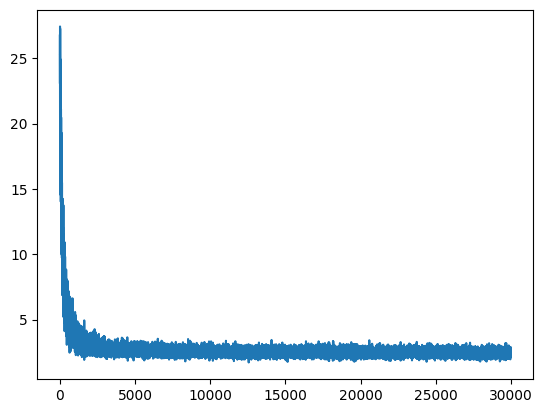

In [198]:
plt.plot(stepi, lossi)

In [199]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.4502, grad_fn=<NllLossBackward0>)

## 3. Train / Dev / Test split
80% train, 10% dev (val), 10% test  
WHY: never touch test set during training or hyperparameter tuning

In [145]:
import random
random.seed(42)
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

# YOUR CODE HERE — build Xtr/Ytr, Xdev/Ydev, Xte/Yte

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


## 4. Initialize the model
Architecture (Bengio 2003):  
`C` — embedding matrix (27, n_embd)  
`W1, b1` — hidden layer weights + bias  
`W2, b2` — output layer weights + bias  

Forward pass:  
1. Look up embeddings: `emb = C[X]` → shape (N, block_size, n_embd)  
2. Concatenate: `emb.view(N, block_size * n_embd)`  
3. Hidden: `h = torch.tanh(emb_cat @ W1 + b1)`  
4. Logits: `logits = h @ W2 + b2`  
5. Loss: cross_entropy(logits, Y)

In [ ]:
g = torch.Generator().manual_seed(2147483647)

n_embd  = 2    # embedding dimensions (start small, visualize later)
n_hidden = 100  # neurons in hidden layer

C  = torch.randn((27, n_embd),                       generator=g)
W1 = torch.randn((block_size * n_embd, n_hidden),    generator=g)
b1 = torch.randn(n_hidden,                           generator=g)
W2 = torch.randn((n_hidden, 27),                     generator=g)
b2 = torch.randn(27,                                 generator=g)

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters), 'parameters')

for p in parameters:
    p.requires_grad = True

## 5. Training loop (minibatches)

In [ ]:
# Training loop with minibatches
# WHY minibatches: full-batch gradient is accurate but slow;
#     stochastic (batch_size ~32) is noisy but fast + acts as regularization

max_steps  = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch
    # YOUR CODE HERE — random sample of batch_size indices from Xtr

    # forward pass
    # YOUR CODE HERE — embed, concat, hidden (tanh), logits, loss

    # backward pass
    for p in parameters:
        p.grad = None
    # YOUR CODE HERE — loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01   # learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

In [ ]:
# Plot loss curve
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

## 6. Evaluate on train / dev split

In [ ]:
# Evaluate loss on train and dev set (no gradient needed)
# WHY: compare train vs dev loss to diagnose underfitting vs overfitting

@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'dev':   (Xdev, Ydev),
        'test':  (Xte, Yte),
    }[split]
    # YOUR CODE HERE — forward pass, compute loss, print
    pass

split_loss('train')
split_loss('dev')

## 7. Visualize the 2D embeddings
Because n_embd=2 we can plot the 27 character embeddings in 2D space.  
Similar characters should cluster together after training.

In [ ]:
# Plot C embeddings — each point is one character
# YOUR CODE HERE — plt.scatter + plt.annotate for each char in itos

## 8. Sample from the model

In [ ]:
# Sample 20 names from the trained model
# Start with context = [0, 0, 0] (all dots)
# At each step: embed context → hidden → logits → softmax → multinomial sample
# Stop when '.' (index 0) is sampled

g = torch.Generator().manual_seed(2147483647 + 10)

# YOUR CODE HERE